In [1]:
# %pip install -r requirements.txt

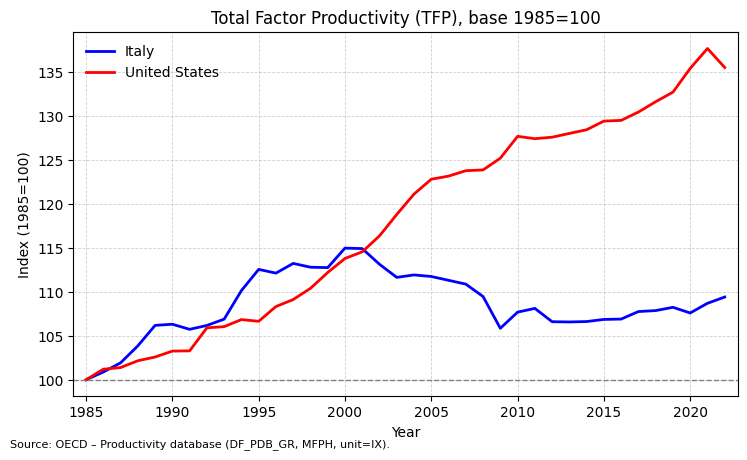

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

# === 1) OECD API extraction (SDMX v3) ===
BASE = "https://sdmx.oecd.org/public/rest/data"
FLOW = "OECD.SDD.TPS,DSD_PDB@DF_PDB_GR,1.0"
KEY = "ITA+USA.A.MFPH._T.IX.V._Z._Z._Z"
PARAMS = "dimensionAtObservation=AllDimensions&format=csvfilewithlabels&startPeriod=1985&endPeriod=2023"
URL = f"{BASE}/{FLOW}/{KEY}?{PARAMS}"

resp = requests.get(URL, headers={"Accept": "text/csv", "User-Agent": "oecd-sdmx-demo"})
resp.raise_for_status()
df = pd.read_csv(StringIO(resp.text))

# === 2) Year × country table, normalisation with 1985=100 ===
df = df[["REF_AREA", "TIME_PERIOD", "OBS_VALUE"]].dropna()
df["OBS_VALUE"] = pd.to_numeric(df["OBS_VALUE"], errors="coerce")
wide = df.pivot(index="TIME_PERIOD", columns="REF_AREA", values="OBS_VALUE").sort_index()
norm = wide / wide.loc[1985] * 100  # base 1985=100

# === 3) Chart with legend on the left ===
fig, ax = plt.subplots(figsize=(7.5, 4.6))

ax.plot(norm.index, norm["ITA"], color="blue", linewidth=2, label="Italy")
ax.plot(norm.index, norm["USA"], color="red", linewidth=2, label="United States")

# Baseline at 100
ax.axhline(100, linestyle="--", linewidth=1, color="gray")

# Titles and axes
ax.set_title("Total Factor Productivity (TFP), base 1985=100")
ax.set_xlabel("Year")
ax.set_ylabel("Index (1985=100)")

# Light grid
ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_axisbelow(True)

# Legend in the upper-left corner
ax.legend(loc="upper left", fontsize=10, frameon=False)

# Margins and layout
ax.margins(x=0.02, y=0.05)
fig.tight_layout()

# Source
fig.text(
    0.01,
    0.01,
    "Source: OECD – Productivity database (DF_PDB_GR, MFPH, unit=IX).",
    ha="left",
    va="bottom",
    fontsize=8
)

plt.show()